# Customer Churn Prediction using Random Forest
**Crystal Ford | Data Science Intern Candidate - University of Chicago**

This notebook demonstrates the process of predicting customer churn using Random Forest. It includes data cleaning, feature engineering, train/validation/test split, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("churn_clean.csv")
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,...,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,...,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,...,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,...,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,...,149.948316,271.493436,4,4,4,3,4,4,4,5


## Step 1: Data Cleaning
First, I drop irrelevant columns, map Yes/No to 1/0, and one-hot encode remaining object columns.

In [2]:
# Drop irrelevant columns
columns_to_drop = [
    'CaseOrder', 'Customer_id', 'Interaction', 'UID', 'City', 'State', 'County', 'Zip', 'Lat', 'Lng',
    'Email', 'Contacts', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8'
]
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Safely map binary columns
binary_map = {'yes': 1, 'no': 0}
binary_columns = [
    'Techie', 'Port_modem', 'Tablet', 'Phone', 'Multiple',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]
for col in binary_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(binary_map)

# Drop rows with NaN in 'Churn'
df = df.dropna(subset=['Churn'])

# One-hot encode remaining object columns
object_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=object_cols, drop_first=False)

# Save cleaned file
df.to_csv("churn_cleaned.csv", index=False)
df.head()

,Population,Children,Age,Income,Churn,Outage_sec_perweek,Yearly_equip_failure,Techie,Port_modem,Tablet,...,Gender_Nonbinary,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check
0,38,0,68,28561.99,0,7.978323,1,0,1,1,...,False,False,True,False,False,True,False,True,False,False
1,10446,1,27,21704.77,1,11.699080,1,1,0,1,...,False,True,False,False,False,True,True,False,False,False
2,3735,4,50,9609.57,0,10.752800,1,1,1,0,...,False,False,False,True,True,False,False,True,False,False
3,13863,1,48,18925.23,0,14.913540,0,1,0,0,...,False,False,False,True,True,False,False,False,False,True
4,11352,0,83,40074.19,1,8.147417,1,0,1,0,...,False,True,False,False,False,True,False,False,False,True


## Step 2: Split Dataset
I split the dataset into training, validation, and test sets (60/20/20).

In [3]:
from sklearn.model_selection import train_test_split

# Load cleaned data
df_clean = pd.read_csv("churn_cleaned.csv")
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

## Step 3: Train Random Forest (Baseline)
I train a default Random Forest model and evaluate on the validation set.

Validation Accuracy: 0.8975
Validation Precision: 0.8896882494004796
Validation Recall: 0.7
Validation F1 Score: 0.7835269271383316
Validation AUC-ROC: 0.9591426004364011


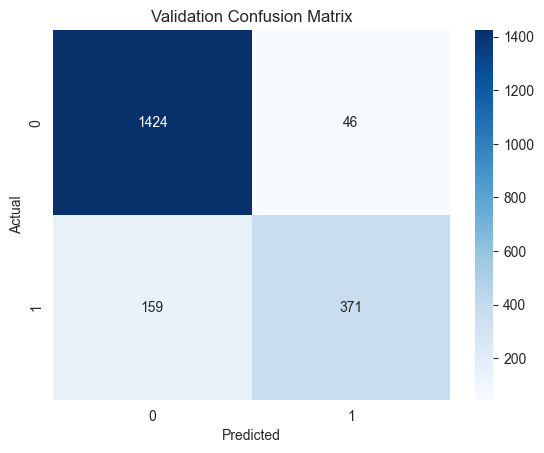

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train baseline model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_val_pred = rf.predict(X_val)
y_val_proba = rf.predict_proba(X_val)[:, 1]

# Print metrics
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation F1 Score:", f1_score(y_val, y_val_pred))
print("Validation AUC-ROC:", roc_auc_score(y_val, y_val_proba))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Test Accuracy: 0.882
Test Precision: 0.8533653846153846
Test Recall: 0.6698113207547169
Test F1 Score: 0.7505285412262156
Test AUC-ROC: 0.9509613656783468


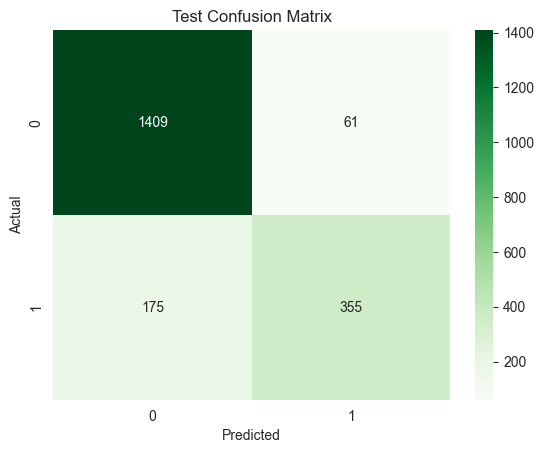

In [5]:
# Evaluate baseline model on the test set
y_test_pred = rf.predict(X_test)
y_test_proba = rf.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Test AUC-ROC:", roc_auc_score(y_test, y_test_proba))

# Plot confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Summary

- Built a Random Forest model to predict customer churn.
- Performed data cleaning, binary conversion, and one-hot encoding.
- Achieved strong validation and test metrics (F1, AUC).
- Demonstrates a full ML workflow from raw data to predictions.

This example reflects my practical approach to problem solving and attention to clean, readable code.
